2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import lib.stats.stats as st
import lib.annotation.Result_Prep as rp
import config.config as conf
import matplotlib as mpl
import matplotlib.lines as mlines
import os

INFO 01-08 11:04:09 [__init__.py:216] Automatically detected platform cuda.


In [2]:
path = f'{conf.DATA_PATH}/data/llm_annotation_result' 
file_list = os.listdir(path)

In [3]:
r_p = rp.Result_Prep()

In [4]:
ver_list_5 = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=50000) & (int(y)<60000)])
ver_list_10 = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=100000) & (int(y)<110000)])


In [5]:
ver_list = ver_list_5 + ver_list_10
print(ver_list)

['50037', '50038', '50039', '50040', '50041', '50042', '50043', '50044', '50045', '50046', '50047', '50048', '50049', '50050', '50051', '50052', '50053', '50054', '50055', '50056', '50057', '50058', '50059', '50060', '50061', '50062', '50063', '50064', '50065', '50066', '50067', '50068', '50069', '50070', '50071', '50073', '100000', '100001', '100002', '100003', '100004', '100005', '100006', '100007', '100008', '100009', '100010', '100011', '100012', '100013', '100014', '100015', '100016', '100017', '100018', '100019', '100020', '100021', '100022', '100023', '100024', '100025', '100026', '100027', '100028', '100029', '100030', '100031', '100032', '100034', '100035', '100037', '100038', '100039', '100040', '100041', '100042', '100043', '100044', '100045', '100046', '100047', '100048', '100049', '100050', '100051', '100052', '100053', '100054', '100055', '100056', '100057', '100058', '100059', '100060', '100061', '100062', '100063', '100064', '100065', '100066', '100067', '100068', '1000

In [6]:
tot_calc = pd.DataFrame()
df = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

tot_calc.sort_values(by = ['rel_week'], ascending=True, inplace=True)    

In [7]:
m_chk_cnt_0 = tot_calc[tot_calc['o_result'] =='0']
m_chk_cnt_1 = tot_calc[tot_calc['o_result'] =='1']
m_chk_cnt_2 = tot_calc[tot_calc['o_result'] =='2']

In [8]:
m_chk_cnt_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 0 to 0
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  217 non-null    float64
 1   o_result  217 non-null    object 
 2   r_cnt     217 non-null    int64  
 3   tot_cnt   217 non-null    int64  
 4   rate      217 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 10.2+ KB


In [9]:
print(m_chk_cnt_0.loc[m_chk_cnt_0['o_result'].isna(), 'rate'])
print(m_chk_cnt_1.loc[m_chk_cnt_1['o_result'].isna(), 'rate'])
print(m_chk_cnt_2.loc[m_chk_cnt_2['o_result'].isna(), 'rate'])

Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)


In [10]:
m_chk_cnt_0.loc[:, 'o_result'] = '0'
m_chk_cnt_1.loc[:, 'o_result'] = '1'
m_chk_cnt_2.loc[:, 'o_result'] = '2'

In [11]:
def calc_stats(df):
    x = df['rel_week'].values
    y = df['rate'].values
    st_ = st.Stats(x, y, 2, 0.95)
    F_stat, p_value = st_.chow_test()

    return x, y, st_, F_stat, p_value


In [12]:
x = m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)].rel_week.values

In [13]:
m_chk_cnt_0


,rel_week,o_result,r_cnt,tot_cnt,rate
0,-56.0,0,27,65,41.538462
0,-55.0,0,25,35,71.428571
0,-55.0,0,41,72,56.944444
0,-55.0,0,40,70,57.142857
0,-55.0,0,15,30,50.000000
...,...,...,...,...,...
0,97.0,0,7,30,23.333333
0,100.0,0,21,62,33.870968
0,101.0,0,10,31,32.258065
0,101.0,0,12,30,40.000000


In [14]:
result_dict = \
{0 : {0:  calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)]),
        1 : calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=0) & (m_chk_cnt_0['rel_week'] <104)])},

1 : {0:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >=-52) & (m_chk_cnt_1['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >= 0) & (m_chk_cnt_1['rel_week'] < 104)])},

2 : {0:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >=-52) & (m_chk_cnt_2['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >= 0) & (m_chk_cnt_2['rel_week'] < 104)])}
}

In [15]:
calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)])

(array([-52., -51., -51., -51., -51., -51., -47., -47., -47., -47., -47.,
        -47., -43., -42., -42., -42., -42., -42., -39., -38., -38., -38.,
        -38., -38., -35., -34., -34., -34., -34., -34., -30., -30., -30.,
        -30., -30., -30., -26., -25., -25., -25., -25., -25., -22., -21.,
        -21., -21., -21., -21., -17., -16., -16., -16., -16., -16., -13.,
        -12., -12., -12., -12., -12.,  -8.,  -8.,  -8.,  -8.,  -8.,  -8.,
         -4.,  -3.,  -3.,  -3.,  -3.,  -3.,   0.,   1.,   1.,   1.,   1.,
          1.,   5.,   5.,   5.,   5.,   5.,   5.,   9.,  10.,  10.,  10.,
         10.,  10.,  13.,  14.,  14.,  14.,  14.,  14.,  18.,  18.,  18.,
         18.,  18.,  18.,  22.,  23.,  23.,  23.,  23.,  23.,  26.,  27.,
         27.,  27.,  27.,  27.,  31.,  31.,  31.,  31.,  31.,  31.,  35.,
         36.,  36.,  36.,  36.,  36.,  39.,  40.,  40.,  40.,  40.,  40.,
         44.,  44.,  44.,  44.,  44.,  44.,  48.,  49.,  49.,  49.,  49.,
         49.]),
 array([50.76923077, 4

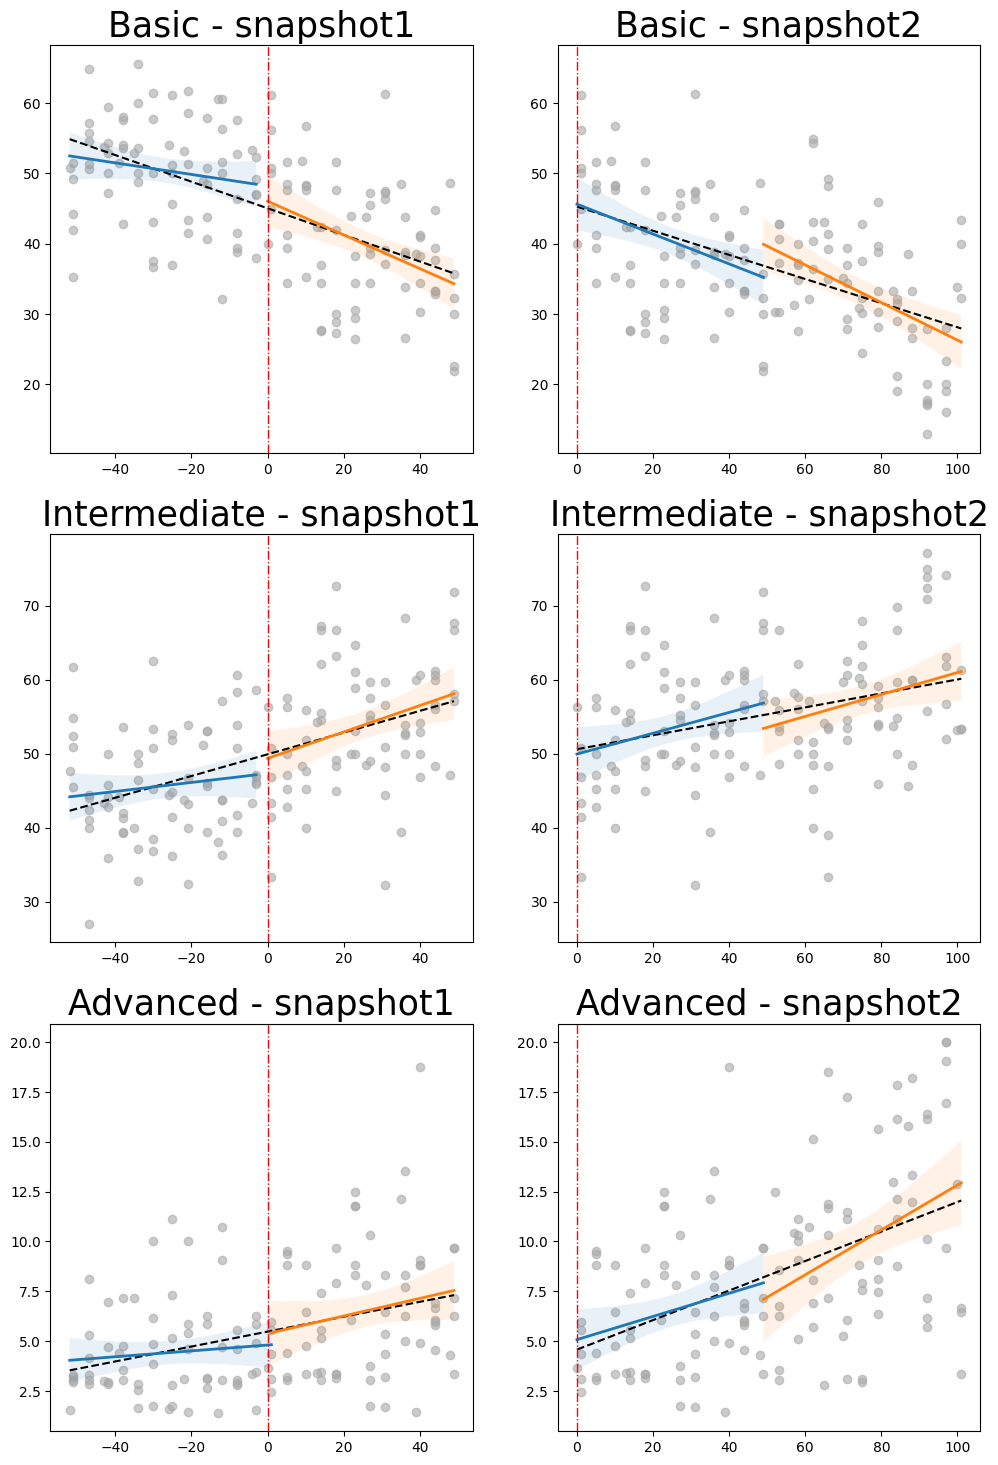

In [16]:
fig, axs = plt.subplots(3, 2, figsize = (12, 18))

diff_dict = {0 : 'Basic', 1 : 'Intermediate', 2 : 'Advanced'}
snapshot_dict = {0 : 'snapshot1', 1 : 'snapshot2'}

for x_idx, snap_dict in result_dict.items():
    axs[x_idx, 1].sharey(axs[x_idx, 0])
    for y_idx, st_param in snap_dict.items():
        x = st_param[0]
        split_idx = int(len(x)/2)
        x_0_1 = x[:split_idx]
        x_0_2 = x[split_idx:]

        axs[x_idx][y_idx].scatter(st_param[0], st_param[1],  alpha=0.6, color='darkgray')
        axs[x_idx][y_idx].plot(st_param[0], st_param[2].y_predict, label="Overall Fit", linestyle="--", color="black")  

        axs[x_idx][y_idx].plot(x_0_1, st_param[2].y1_predict, label="before ChatGPT", linewidth='2')

        axs[x_idx][y_idx].fill_between(x_0_1, st_param[2].y1_predict - st_param[2].y1_conf_interval, st_param[2].y1_predict + st_param[2].y1_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].plot(x_0_2, st_param[2].y2_predict, label="after ChatGPT", linewidth='2')
        axs[x_idx][y_idx].fill_between(x_0_2, st_param[2].y2_predict - st_param[2].y2_conf_interval, st_param[2].y2_predict + st_param[2].y2_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].axvline(x=0,     color='red',    linestyle='-.', linewidth=1)
        axs[x_idx][y_idx].set_title(f"{diff_dict[x_idx]} - {snapshot_dict[y_idx]}", fontsize=25)
        